#Headline Sentiment Stock Predictions


## Introduction and Usage

Boston College CSCI3349 Final Project: Group 6. Analyzes the sentiment of financial headlines to predict whether the DJIA went up or down on a given day.

To run this notebook:
1. Ensure you have the necessary Google Colab permissions and drive access configured.
2. Execute the 'Packages' section to install all required libraries.
3. Run the 'Data Preprocessing' section to load and clean the dataset. This is where you would decide to include / not include the 2008 data as well as set up the output paths to demonstrate the results in generated CSV files.
4. Proceed through the 'Generate Baselines', 'Bag of Words', 'Word2Vec', 'BERT', 'Mistral', and 'VADER Sentiment Analysis' sections to train and evaluate different models, or do each individually.
5. Review the results in the generated CSV files in your Google Drive.

### Libraries and Toolkits Used in this Colab

*   **Data Handling and Analysis:**
    *   `pandas` (pd)
    *   `numpy` (np)
    *   `datasets` (from Hugging Face)

*   **Natural Language Processing (NLP):**
    *   `nltk` (Natural Language Toolkit)
    *   `gensim` (Word2Vec)
    *   `vaderSentiment` (Sentiment Intensity Analyzer)
    *   `transformers` (from Hugging Face)
    *   `mistralai` (Mistral API client)

*   **Machine Learning / Deep Learning Frameworks and Libraries:**
    *   `tensorflow` (tf)
    *   `sklearn` (Scikit-learn) - including `metrics`, `ensemble`, `linear_model`, `naive_bayes`, `neighbors`, `neural_network`, `preprocessing`, `svm`
    *   `keras` (within TensorFlow for `Sequential` model and layers like `Conv1D`, `MaxPooling1D`, `Dropout`, `Dense`, `Flatten`)

*   **Evaluation Metrics:**
    *   `evaluate` (from Hugging Face, for metrics like accuracy and F1-score)

*   **Utilities:**
    *   `re` (Regular Expressions)
    *   `math`
    *   `time`
    *   `ast`
    *   `os`

*   **Google Colab Specific:**
    *   `google.colab` (`drive`)

*   **Other:**
    *   `glob` (for pathnames matching a specified pattern - though not directly used, it's imported)


#Packages:

In [ ]:
!pip install datasets
!pip install transformers
!pip install evaluate
!pip install --upgrade gensim
!pip install nltk
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 973.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 1.2 MB/s eta 0:00:00


In [ ]:
import re
import math
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn import metrics
import nltk
from google.colab import drive
import matplotlib.pyplot as plt

# Data Preprocessing

##Import data:

In [ ]:
drive.mount('/content/drive')
!ls
!ls drive/MyDrive/NLP\ Final\ Project
combined = pd.read_csv('drive/MyDrive/NLP Final Project/Combined_News_DJIA.csv')
djia = pd.read_csv('drive/MyDrive/NLP Final Project/upload_DJIA_table.csv')


Mounted at /content/drive
drive  sample_data
 Combined_News_DJIA.csv			  'NLP Project Progress Report.gdoc'
 DJIA_NLP_Prediction.ipynb		   results
 model_results_excluding_2008.csv	   results_no_2008
 model_results_including_2008.csv	  'Results Visualization.ipynb'
 model_results_yearly_including_2008.csv   upload_DJIA_table.csv
'NLP Final Project.gslides'


# Data cleaning/prep:

In [ ]:

#Check all labels correspond with price movement, and fix those that do not

combined['Date'] = pd.to_datetime(combined['Date'])
djia['Date'] = pd.to_datetime(djia['Date'])
djia['Movement'] = (djia['Close'] > djia['Open']).astype(int)
movement_map = dict(zip(djia['Date'], djia['Movement']))
combined['Movement'] = combined['Date'].map(movement_map)
combined['Match'] = combined['Label'] == combined['Movement']
combined['Match'] = combined['Label'] == combined['Movement']
accuracy_before = combined['Match'].mean()
print(combined.loc[~combined['Match'], ['Date', 'Label', 'Movement']])
combined.loc[~combined['Match'], 'Label'] = combined.loc[~combined['Match'], 'Movement']
combined['Match'] = combined['Label'] == combined['Movement']
accuracy_after = combined['Match'].mean()
print("Accuracy before:", accuracy_before)
print("Accuracy after:", accuracy_after)

# Combine into one text column
headline_cols = [f'Top{i}' for i in range(1, 26)]
combined['Text'] = combined[headline_cols].fillna('').agg(' '.join, axis=1)
print(combined)

#split into test and training
train = combined.sample(n=1600, random_state=42)
test = combined.drop(train.index)
print("Train size:", len(train))
print("Test size:", len(test))

           Date  Label  Movement
0    2008-08-08      0         1
129  2009-02-12      0         1
323  2009-11-18      0         1
430  2010-04-26      1         0
485  2010-07-14      1         0
497  2010-07-30      0         1
561  2010-10-29      1         0
634  2011-02-14      0         1
650  2011-03-09      0         1
893  2012-02-24      0         1
894  2012-02-27      0         1
1013 2012-08-15      0         1
1244 2013-07-19      0         1
1260 2013-08-12      0         1
1307 2013-10-17      0         1
1422 2014-04-03      0         1
1576 2014-11-11      1         0
1577 2014-11-12      0         1
1582 2014-11-19      0         1
1588 2014-11-28      1         0
1606 2014-12-24      1         0
1622 2015-01-20      1         0
1707 2015-05-21      1         0
1755 2015-07-30      0         1
1764 2015-08-12      0         1
1838 2015-11-25      1         0
1839 2015-11-27      0         1
1888 2016-02-09      0         1
1948 2016-05-05      1         0
1957 2016-

### Include 2008 Tag

This tag here indicates whether our models will be trained on the 2008 data or not. By default, it will be set as true. However, if you want to remove the 2008 data, please change the value below to False.

In [ ]:
## Flag to indicate whether or not to test on data that is includes vs excludes 2008 data
INCLUDE_2008 = True

## Remove 2008 Data

In [ ]:
if INCLUDE_2008 == False:
  ## Filter out 2008 Data
  combined_no_2008 = combined[combined['Date'].dt.year != 2008].copy()

  # rebuild Text just to be safe
  headline_cols = [f'Top{i}' for i in range(1, 26)]
  combined_no_2008['Text'] = combined_no_2008[headline_cols].fillna('').agg(' '.join, axis=1)

  # use fraction instead of hardcoded n=1600 since data is smaller now
  # set train and test variables to exclude 2008
  train = combined_no_2008.sample(frac=0.8, random_state=42)
  test = combined_no_2008.drop(train_no_2008.index)

  print("Filtered dataset size (excluding 2008):", len(combined_no_2008))
  print("Train size:", len(train_no_2008))
  print("Test size:", len(test_no_2008))

## Setting up PLT Color Palette

Palette shared from the Results Visualization Colab Notebook.

In [ ]:
# Colour palette
BG      = "#fffcf8"   # page background
PANEL   = "#f5f0e8"   # chart background
BLUE    = "#2563eb"   # Word2Vec
ORANGE  = "#ea580c"   # Bag of Words
GREEN   = "#16a34a"   # Neural / LLM
PURPLE  = "#7c3aed"   # fallback / other
YELLOW  = "#ca8a04"   # VADER
GRID    = "#e0d8cc"   # gridlines
TEXT    = "#1a1a1a"   # primary text
SUBTEXT = "#666666"   # secondary text / baselines

## Comparing Balance Between Including vs Excluding 2008

Class Balance: Including vs. Excluding 2008


,Including 2008 Count,Including 2008 %,Excluding 2008 Count,Excluding 2008 %
DJIA Down (0),912,45.85,859,45.5
DJIA Up (1),1077,54.15,1029,54.5


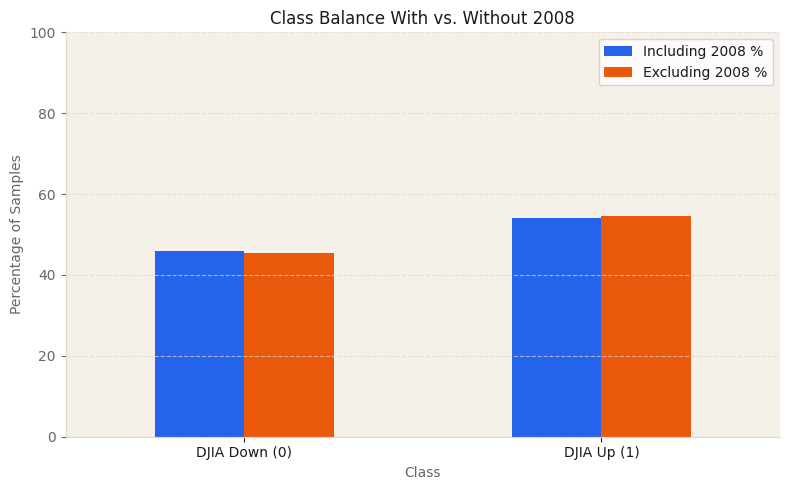

In [ ]:
# Class Balance: Including vs. Excluding 2008
combined['Date'] = pd.to_datetime(combined['Date'])

# Full dataset including 2008
including_2008_counts = combined['Label'].value_counts().sort_index()
including_2008_percents = combined['Label'].value_counts(normalize=True).sort_index() * 100

# Dataset excluding 2008
combined_no_2008 = combined[combined['Date'].dt.year != 2008].copy()
excluding_2008_counts = combined_no_2008['Label'].value_counts().sort_index()
excluding_2008_percents = combined_no_2008['Label'].value_counts(normalize=True).sort_index() * 100

# Put into clean table
class_balance = pd.DataFrame({
    "Including 2008 Count": including_2008_counts,
    "Including 2008 %": including_2008_percents.round(2),
    "Excluding 2008 Count": excluding_2008_counts,
    "Excluding 2008 %": excluding_2008_percents.round(2)
})

class_balance.index = ["DJIA Down (0)", "DJIA Up (1)"]

print("Class Balance: Including vs. Excluding 2008")
display(class_balance)


plot_df = class_balance[["Including 2008 %", "Excluding 2008 %"]]

fig, ax = plt.subplots(figsize=(8, 5))
plot_df.plot(kind="bar", ax=ax, color=[BLUE, ORANGE]) # Apply custom colors

plt.title("Class Balance With vs. Without 2008", color=TEXT)
plt.ylabel("Percentage of Samples", color=SUBTEXT)
plt.xlabel("Class", color=SUBTEXT)
plt.xticks(rotation=0, color=TEXT)
plt.yticks(color=SUBTEXT)
plt.ylim(0, 100)
plt.legend(title="", frameon=True, loc='upper right', labelcolor=TEXT) # Changed loc and frameon
ax.set_facecolor(PANEL)
ax.tick_params(axis='x', colors=TEXT)
ax.tick_params(axis='y', colors=SUBTEXT)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.yaxis.grid(True, linestyle='--', color=GRID, alpha=0.7)
plt.tight_layout()
plt.show()

## Keeping Track of Results

In [ ]:
if INCLUDE_2008:
  RESULTS_PATH = "/content/drive/MyDrive/NLP Final Project/model_results_including_2008.csv"
  YEARLY_RESULTS_PATH = "/content/drive/MyDrive/NLP Final Project/model_results_yearly_including_2008.csv"
  BERT_RESULTS_PATH = "/content/drive/MyDrive/NLP Final Project/results"
else:
  RESULTS_PATH = "/content/drive/MyDrive/NLP Final Project/model_results_excluding_2008.csv"
  YEARLY_RESULTS_PATH = "/content/drive/MyDrive/NLP Final Project/model_results_yearly_excluding_2008.csv"
  BERT_RESULTS_PATH = "/content/drive/MyDrive/NLP Final Project/results_no_2008"


In [ ]:
def add_result(model_name, y_true=None, y_pred=None,
               accuracy=None, precision=None, recall=None, f1=None):

    # load existing results from CSV, or start fresh if file doesn't exist yet
    try:
        existing_df = pd.read_csv(RESULTS_PATH)
        existing = existing_df.to_dict("records")
    except FileNotFoundError:
        existing = []

    # remove the model's existing row if present so we can overwrite it
    existing = [r for r in existing if r["Model"] != model_name]

    # (standard path) if raw predictions are passed in, compute all metrics from scratch
    if y_true is not None and y_pred is not None:
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='weighted', zero_division=0
        )
        accuracy = accuracy_score(y_true, y_pred)
    # else metrics must be passed in directly (BERT uses trainer.evaluate() and doesn't produce raw predictions by default)

    existing.append({
        "Model":                model_name,
        "Accuracy":             accuracy,
        "Precision_weighted":   precision,
        "Recall_weighted":      recall,
        "F1_weighted":          f1
    })

    # sort by accuracy descending and overwrite the CSV
    pd.DataFrame(existing).sort_values(by="Accuracy", ascending=False).to_csv(
        RESULTS_PATH, index=False
    )
    print(f"'{model_name}' saved to CSV")

In [ ]:
def add_yearly_result(model_name, y_true, y_pred, dates):
    # Load existing CSV
    try:
        existing_df = pd.read_csv(YEARLY_RESULTS_PATH)
        existing = existing_df.to_dict("records")
    except FileNotFoundError:
        existing = []

    # Remove model if it already exists
    existing = [r for r in existing if r["Model"] != model_name]

    # Build per-year accuracy
    temp_df = pd.DataFrame({
        "Year":   pd.to_datetime(dates).dt.year,
        "y_true": y_true,
        "y_pred": y_pred
    })

    for year, group in temp_df.groupby("Year"):
        existing.append({
            "Model":    model_name,
            "Year":     year,
            "Accuracy": accuracy_score(group["y_true"], group["y_pred"]),
            "N":        len(group)
        })

    pd.DataFrame(existing).sort_values(["Model", "Year"]).to_csv(
        YEARLY_RESULTS_PATH, index=False
    )
    print(f"'{model_name}' yearly data saved to CSV")

# Generate Baselines

Generates the three baselines chosen for this project, those being a majority baseline, a random baseline, and a previous day momentum baseline.

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
# Majority Baseline
majority_label = train['Label'].mode()[0]
majority_predictions = [majority_label] * len(test)
majority_accuracy = accuracy_score(test['Label'], majority_predictions)
add_result("Baseline - Majority", test['Label'], majority_predictions)
add_yearly_result("Baseline - Majority", test['Label'], majority_predictions, test['Date'])

# Random Baseline
np.random.seed(42)
random_predictions = np.random.randint(0, 2, size=len(test))
random_accuracy = accuracy_score(test['Label'], random_predictions)
sorted_combined = combined.sort_values(by='Date')
sorted_combined['Previous_Day_Label'] = sorted_combined['Label'].shift(1)
add_result("Baseline - Random", test['Label'], random_predictions)
add_yearly_result("Baseline - Random", test['Label'], random_predictions, test['Date'])

# Momentum Baseline
prev_day_label_map = sorted_combined.set_index('Date')['Previous_Day_Label'].dropna().to_dict()
test_with_prev_label = test.sort_values(by='Date').copy()
test_with_prev_label = pd.merge(test_with_prev_label, sorted_combined[['Date', 'Previous_Day_Label']], on='Date', how='left')
test_with_prev_label['Previous_Day_Label'] = test_with_prev_label['Previous_Day_Label'].fillna(majority_label)
previous_day_predictions = test_with_prev_label['Previous_Day_Label'].astype(int)

# drop any rows where Label is NaN before scoring
clean = test_with_prev_label.dropna(subset=['Label', 'Previous_Day_Label'])
previous_day_accuracy = accuracy_score(clean['Label'], clean['Previous_Day_Label'].astype(int))

add_result("Baseline - Momentum", clean['Label'], clean['Previous_Day_Label'].astype(int))
add_yearly_result("Baseline - Momentum", clean['Label'], clean['Previous_Day_Label'].astype(int), clean['Date'])

print(f"Majority Baseline Accuracy: {majority_accuracy:.4f}")
print(f"Random Baseline Accuracy: {random_accuracy:.4f}")
print(f"Previous Day Momentum Baseline Accuracy: {previous_day_accuracy:.4f}")

'Baseline - Majority' saved to CSV
'Baseline - Majority' yearly data saved to CSV
'Baseline - Random' saved to CSV
'Baseline - Random' yearly data saved to CSV
'Baseline - Momentum' saved to CSV
'Baseline - Momentum' yearly data saved to CSV
Majority Baseline Accuracy: 0.4833
Random Baseline Accuracy: 0.4987
Previous Day Momentum Baseline Accuracy: 0.4807


#Bag of Words

In [ ]:
nltk.download('stopwords')
from nltk import FreqDist
import glob
from nltk.corpus import stopwords
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Dense, Flatten

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
nltk.download('stopwords')
stops = stopwords.words('english')
stops.extend([",", ".", "!", "?", "'", '"', "I", "i", "n't", "'ve", "'d", "'s"])
poswords = []
negwords = []
allwords = []

def process_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = list(set([w for w in words if w not in stops]))
    return words

for _, row in train.iterrows():
    words = process_text(row['Text'])
    if row['Label'] == 1:
        poswords.append(words)
    else:
        negwords.append(words)

    allwords.extend(words)

print("Number of positive docs:", len(poswords))
print("Number of negative docs:", len(negwords))
print("Vocabulary size:", len(allwords))

wfreq = FreqDist(allwords)
top1000 = wfreq.most_common(1000)

training = []
traininglabel = []
#get all words sorted into negative and positive days
for p in poswords:
    vec = []
    for t in top1000:
        if t[0] in p:
            vec.append(1)
        else:
            vec.append(0)
    training.append(vec)
    traininglabel.append(1)

for n in negwords:
    vec = []
    for t in top1000:
        if t[0] in n:
            vec.append(1)
        else:
            vec.append(0)
    training.append(vec)
    traininglabel.append(0)


print(len(traininglabel))
print(len(training[0]))
print(training[0])

testing = []
testinglabel = []
#extract features for models
for _, row in test.iterrows():
    text = row['Text']
    words = re.sub(r'[^a-zA-Z\s]', '', text).lower().split()
    rw = words
    vec = []
    for t in top1000:
        if t[0] in rw:
            vec.append(1)
        else:
            vec.append(0)
    testing.append(vec)
    testinglabel.append(row['Label'])

print(len(testing))
print(len(testing[0]))

## Multi-Layer Perceptron
clf = MLPClassifier(solver='adam', alpha=1e-5, hidden_layer_sizes=(2, 2), random_state=1, max_iter=500)
clf.fit(training, traininglabel)
predicted = clf.predict(testing)
print("Accuracy of Multi-Layer Perceptron")
print(metrics.classification_report(testinglabel, predicted))
add_result("Bag of Words + Multilayer Perceptron", test['Label'], predicted)
add_yearly_result("Bag of Words + Multilayer Perceptron", testinglabel, predicted, test['Date'])

## Logistic Regression
lr = LogisticRegression()
lr.fit(training, traininglabel)
predicted = lr.predict(testing)
print("Accuracy of Logistic Regression")
print(metrics.classification_report(testinglabel, predicted))
add_result("Bag of Words + Logistic Regression", test['Label'], predicted)
add_yearly_result("Bag of Words + Logistic Regression", testinglabel, predicted, test['Date'])

## Naive Bayes
nb = GaussianNB()
nb.fit(training, traininglabel)
predicted = nb.predict(testing)
print("Accuracy of Naive Bayes")
print(metrics.classification_report(testinglabel, predicted))
add_result("Bag of Words + Naive Bayes", test['Label'], predicted)
add_yearly_result("Bag of Words + Naive Bayes", testinglabel, predicted, test['Date'])

## KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(training, traininglabel)
predicted = knn.predict(testing)

print("Accuracy of KNN")
print(metrics.classification_report(testinglabel, predicted))
add_result("Bag of Words + KNN", test['Label'], predicted)
add_yearly_result("Bag of Words + KNN", testinglabel, predicted, test['Date'])



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Number of positive docs: 889
Number of negative docs: 711
Vocabulary size: 410123
1600
1000
[1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0

### CNN

In [ ]:
X_train = np.array(training)
X_test = np.array(testing)
y_train = np.array(traininglabel)
y_test = np.array(testinglabel)

X_train = X_train.reshape(-1, 1000, 1)
X_test = X_test.reshape(-1, 1000, 1)

print('Shape of training data: ')
print(X_train.shape)
print(y_train.shape)
print('Shape of test data: ')
print(X_test.shape)
print(y_test.shape)

model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification (positive/negative)
])
# Compile the model
# Again, you change the optimize, the loss function, or what metric you'd like report
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print summary
model.summary()
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Add Result
bow_probs = model.predict(X_test, verbose=0)
bow_preds = (bow_probs > 0.5).astype("int32").flatten()
add_result("Bag of Words + CNN", y_test, bow_preds)
add_yearly_result("Bag of Words + CNN", y_test, bow_preds, test['Date'])


Shape of training data: 
(1600, 1000, 1)
(1600,)
Shape of test data: 
(389, 1000, 1)
(389,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.5256 - loss: 0.7030 - val_accuracy: 0.4833 - val_loss: 0.6955
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.5594 - loss: 0.6840 - val_accuracy: 0.4833 - val_loss: 0.6990
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.5700 - loss: 0.6793 - val_accuracy: 0.4859 - val_loss: 0.7028
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.5738 - loss: 0.6736 - val_accuracy: 0.4807 - val_loss: 0.6960
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.6044 - loss: 0.6598 - val_accuracy: 0.4910 - val_loss: 0.6970
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - accuracy: 0.6162 - loss: 0.6519 - val_accuracy: 0.4756 - val_loss: 0.7127
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.6219 - loss: 0.6352 - val_accuracy: 0.4756 - val_loss: 0.7206
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.6587 - loss: 0.6180 - val_accuracy: 0

##Word2Vec

In [ ]:
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Dense, Flatten

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
toksents = []
train_day_tokens = []

for text in train['Text']:
    alltext = str(text)
    alltext = alltext.replace("\n", " ")
    sentences = nltk.sent_tokenize(alltext)

    day_tokens = []
    for sentence in sentences:
        sent_tokens = nltk.word_tokenize(sentence)
        toksents.append(sent_tokens)
        day_tokens.extend(sent_tokens)

    train_day_tokens.append(day_tokens)



# Build test day tokens
test_day_tokens = []

for text in test['Text']:
    alltext = str(text)
    alltext = alltext.replace("\n", " ")
    sentences = nltk.sent_tokenize(alltext)

    day_tokens = []
    for sentence in sentences:
        sent_tokens = nltk.word_tokenize(sentence)
        day_tokens.extend(sent_tokens)

    test_day_tokens.append(day_tokens)


# Train the Word2Vec model
model = Word2Vec(
    toksents,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    epochs=10
)


# Average all word vectors in one day
def average_day_vector(tokens, model):
    vectors = []

    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


# Create feature matrices
X_train_w2v = np.array([average_day_vector(tokens, model) for tokens in train_day_tokens])
X_test_w2v = np.array([average_day_vector(tokens, model) for tokens in test_day_tokens])

y_train = train['Label'].values
y_test = test['Label'].values


# Train classifier
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_w2v, y_train)

preds = clf.predict(X_test_w2v)

In [ ]:
print("Word2Vec feature shapes:")
print("X_train_w2v:", X_train_w2v.shape)
print("X_test_w2v:", X_test_w2v.shape)

# Multi-Layer Perceptron
clf = MLPClassifier(solver='adam', alpha=1e-5, hidden_layer_sizes=(16, 16), random_state=1, max_iter=500)
clf.fit(X_train_w2v, y_train)
predicted = clf.predict(X_test_w2v)
print("\nWord2Vec + Multi-Layer Perceptron")
print("Accuracy:", metrics.accuracy_score(y_test, predicted))
print(metrics.classification_report(y_test, predicted))
add_result("Word2Vec + Multi-Layer Perceptron", y_test, predicted)
add_yearly_result("Word2Vec + Multi-Layer Perceptron", y_test, predicted, test['Date'])

# Logistic Regression
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_w2v, y_train)
predicted = clf.predict(X_test_w2v)
print("\nWord2Vec + Logistic Regression")
print("Accuracy:", metrics.accuracy_score(y_test, predicted))
print(metrics.classification_report(y_test, predicted))
add_result("Word2Vec + Logistic Regression", y_test, predicted)
add_yearly_result("Word2Vec + Logistic Regression", y_test, predicted, test['Date'])

# Naive Bayes
clf = GaussianNB()
clf.fit(X_train_w2v, y_train)
predicted = clf.predict(X_test_w2v)
print("\nWord2Vec + Naive Bayes")
print("Accuracy:", metrics.accuracy_score(y_test, predicted))
print(metrics.classification_report(y_test, predicted))
add_result("Word2Vec + Naive Bayes", y_test, predicted)
add_yearly_result("Word2Vec + Naive Bayes", y_test, predicted, test['Date'])

# KNN
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train_w2v, y_train)
predicted = clf.predict(X_test_w2v)
print("\nWord2Vec + KNN")
print("Accuracy:", metrics.accuracy_score(y_test, predicted))
print(metrics.classification_report(y_test, predicted))
add_result("Word2Vec + KNN", y_test, predicted)
add_yearly_result("Word2Vec + KNN", y_test, predicted, test['Date'])

# Linear SVM
clf = LinearSVC(max_iter=5000, random_state=42)
clf.fit(X_train_w2v, y_train)
predicted = clf.predict(X_test_w2v)
print("\nWord2Vec + Linear SVM")
print("Accuracy:", metrics.accuracy_score(y_test, predicted))
print(metrics.classification_report(y_test, predicted))
add_result("Word2Vec + Linear SVM", y_test, predicted)
add_yearly_result("Word2Vec + Linear SVM", y_test, predicted, test['Date'])


Word2Vec feature shapes:
X_train_w2v: (1600, 100)
X_test_w2v: (389, 100)

Word2Vec + Multi-Layer Perceptron
Accuracy: 0.5501285347043702
              precision    recall  f1-score   support

           0       0.61      0.37      0.46       201
           1       0.52      0.74      0.62       188

    accuracy                           0.55       389
   macro avg       0.57      0.56      0.54       389
weighted avg       0.57      0.55      0.53       389

'Word2Vec + Multi-Layer Perceptron' saved to CSV
'Word2Vec + Multi-Layer Perceptron' yearly data saved to CSV

Word2Vec + Logistic Regression
Accuracy: 0.4910025706940874
              precision    recall  f1-score   support

           0       0.55      0.08      0.14       201
           1       0.49      0.93      0.64       188

    accuracy                           0.49       389
   macro avg       0.52      0.51      0.39       389
weighted avg       0.52      0.49      0.38       389

'Word2Vec + Logistic Regression' saved

In [ ]:
# Use the Word2Vec features you already created
X_train = np.array(X_train_w2v)
X_test = np.array(X_test_w2v)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Reshape for Conv1D: (samples, timesteps, channels)
X_train = X_train.reshape(-1, 100, 1)
X_test = X_test.reshape(-1, 100, 1)

print('Shape of training data: ')
print(X_train.shape)
print(y_train.shape)
print('Shape of test data: ')
print(X_test.shape)
print(y_test.shape)

model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(100, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),

    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()
model.fit(X_train, y_train, epochs=25, batch_size=32, validation_data=(X_test, y_test))

# Add Result
w2v_probs = model.predict(X_test, verbose=0)
w2v_preds = (w2v_probs > 0.5).astype("int32").flatten()
add_result("Word2Vec + CNN", y_test, w2v_preds)
add_yearly_result("Word2Vec + CNN", y_test, w2v_preds, test['Date'])


Shape of training data: 
(1600, 100, 1)
(1600,)
Shape of test data: 
(389, 100, 1)
(389,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 98, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 47, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1472)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        94,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,673 (393.25 KB)

 Trainable params: 100,673 (393.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5431 - loss: 0.6926 - val_accuracy: 0.4833 - val_loss: 0.6988
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5431 - loss: 0.6886 - val_accuracy: 0.4833 - val_loss: 0.6996
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5519 - loss: 0.6908 - val_accuracy: 0.4833 - val_loss: 0.6963
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5587 - loss: 0.6900 - val_accuracy: 0.4833 - val_loss: 0.6971
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5550 - loss: 0.6890 - val_accuracy: 0.4833 - val_loss: 0.6963
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5550 - loss: 0.6878 - val_accuracy: 0.4833 - val_loss: 0.6978
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5500 - loss: 0.6885 - val_accuracy: 0.4833 - val_loss: 0.6997
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5575 - loss: 0.6897 - val_accuracy: 0.4833 - v

## BERT

In [ ]:
import os
from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from evaluate import load
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

In [ ]:
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
# load the DistilBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# convert pandas DataFrames to HuggingFace Dataset format
# rename 'Label' to 'labels' as the Trainer expects this column name
hf_train = Dataset.from_pandas(train.rename(columns={'Label': 'labels'}))
hf_test  = Dataset.from_pandas(test.rename(columns={'Label': 'labels'}))

def preprocess_function(examples):
    # tokenize the Text column, truncating anything longer than the model's max length
    return tokenizer(examples['Text'], truncation=True)

# apply tokenization
tokenized_train = hf_train.map(preprocess_function, batched=True)
tokenized_test  = hf_test.map(preprocess_function,  batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/389 [00:00<?, ? examples/s]

In [ ]:
# pad sequences to the longest in each batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# load DistilBERT with a classification head on top, 2 output labels (0 = decrease, 1 = increase)
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

def compute_metrics(eval_pred):
    # load evaluation metrics from HuggingFace evaluate library
    load_accuracy = load("accuracy")
    load_f1 = load("f1")

    logits, labels = eval_pred

    # convert raw logits to class predictions by taking the argmax
    predictions = np.argmax(logits, axis=-1)

    accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = load_f1.compute(predictions=predictions, references=labels)["f1"]
    return {"accuracy": accuracy, "f1": f1}


training_args = TrainingArguments(
    output_dir=BERT_RESULTS_PATH,       # where to save checkpoints
    learning_rate=2e-5,                 # learning rate
    per_device_train_batch_size=16,     # batch size for training
    per_device_eval_batch_size=16,      # batch size for evaluation
    num_train_epochs=5,                 # number of full passes through the training data
    weight_decay=0.01,                  # L2 regularization to prevent overfitting
    report_to="none"
)

trainer = Trainer(
    model=model,                        # DistilBERT model
    args=training_args,                 # training args defined above
    train_dataset=tokenized_train,      # tokenized training data
    eval_dataset=tokenized_test,        # tokenized test data for evaluation
    processing_class=tokenizer,         # tokenizer for processing inputs
    data_collator=data_collator,        # handles padding per batch
    compute_metrics=compute_metrics,    # function to compute accuracy and F1
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer.train()

In [ ]:
# Evaluate on test data and add to results
bert_eval = trainer.evaluate()
add_result("BERT",
           accuracy=bert_eval["eval_accuracy"],
           f1=bert_eval["eval_f1"],
           precision=np.nan,
           recall=np.nan)

In [ ]:
# Use .predict in order to extract the yearly data from BERT
bert_preds = trainer.predict(tokenized_test)
y_pred_bert = np.argmax(bert_preds.predictions, axis=-1)
y_true_bert = bert_preds.label_ids

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
# Save Yearly Data
add_yearly_result("BERT", y_true_bert, y_pred_bert, test["Date"])

'BERT' yearly data saved to CSV


## Mistral

In [ ]:
!pip install mistralai

In [ ]:
from mistralai.client import Mistral
import time
from sklearn.metrics import classification_report

In [ ]:
# initialize the Mistral client with API key and specify the model to use
client = Mistral(api_key="NHSMqrFBGw8xfdBt0fGcZAvdJGu33Nn8")
MODEL = "mistral-large-latest"

### Zero Shot

In [ ]:
predictions_zero = []

for index, row in test.iterrows():
    headlines = row["Text"]

    # prompt Mistral as a financial analyst and constrain output to 0 or 1
    prompt = f"""You are a financial analyst. Based on the following 25 news headlines from a single day, predict whether the Dow Jones Industrial Average (DJIA) closed higher or lower that day.
Headlines: {headlines}
Respond with only a single digit: '1' if the DJIA increased, '0' if it decreased. Do not explain your answer."""

    MESSAGES = [{"role": "user", "content": prompt}]

    # retry loop to handle rate limiting
    # exponential backoff: waits 5, 10, 20, 40, 80 seconds between attempts
    for attempt in range(5):
        try:
            completion = client.chat.complete(model=MODEL, messages=MESSAGES)
            break
        except Exception as e:
            if "429" in str(e):
                wait = 5 * (2 ** attempt)
                time.sleep(wait)
            else:
                raise  # raise any non-rate-limit errors immediately

    predictions_zero.append(completion.choices[0].message.content.strip())
    time.sleep(5)  # delay between calls to avoid hitting rate limit

# filter out any responses that aren't a clean 0 or 1
npredictions_zero = [int(p) for p in predictions_zero if p in ("0", "1")]

# print final prediction vs actual for the last row processed
print(f"Row {index} | Predicted: {completion.choices[0].message.content.strip()} | Actual: {row['Label']}")
print(classification_report(test["Label"][:len(npredictions_zero)], npredictions_zero))

Row 1985 | Predicted: 0 | Actual: 1
              precision    recall  f1-score   support

           0       0.52      0.99      0.68       201
           1       0.33      0.01      0.01       188

    accuracy                           0.51       389
   macro avg       0.42      0.50      0.34       389
weighted avg       0.43      0.51      0.36       389



In [ ]:
add_result("Mistral - Zero Shot", test["Label"], npredictions_zero)

'Mistral - Zero Shot' saved to CSV


In [ ]:
# separate training data by labe
shot_zeros = train[train["Label"] == 0].copy()
shot_ones  = train[train["Label"] == 1].copy()

# extract year from date to enforce no duplicate years across examples
shot_zeros["Year"] = pd.to_datetime(shot_zeros["Date"]).dt.year
shot_ones["Year"]  = pd.to_datetime(shot_ones["Date"]).dt.year

# sample from each label group, ensuring no two examples come from the same year
used_years = set()

zero_samples = []
for year, group in shot_zeros.groupby("Year"):
    if year not in used_years and len(zero_samples) < 1:  # take 1 zero example
        zero_samples.append(group.sample(n=1, random_state=42))
        used_years.add(year)

one_samples = []
for year, group in shot_ones.groupby("Year"):
    if year not in used_years and len(one_samples) < 2:  # take 2 one examples
        one_samples.append(group.sample(n=1, random_state=42))
        used_years.add(year)

# combine and shuffle so examples aren't presented in label order to Mistral
shot_pool = pd.concat(one_samples + zero_samples).sample(frac=1, random_state=42).reset_index(drop=True)

# build a dictionary of 3 examples for use across all shot conditions
examples = {
    i+1: {
        "date":      shot_pool.iloc[i]["Date"],
        "headlines": shot_pool.iloc[i]["Text"],
        "label":     shot_pool.iloc[i]["Label"]
    }
    for i in range(3)
}

# preview each example
for i, ex in examples.items():
    print(f"Example {i}:")
    print(f"  Date:      {ex['date']}")
    print(f"  Label:     {ex['label']}")
    print(f"  Headlines: {ex['headlines'][:100]}...")
    print()

Example 1:
  Date:      2009-03-06 00:00:00
  Label:     1
  Headlines: b'The Economist: "... the war on drugs has been a disaster.... the least bad policy is to legalise d...

Example 2:
  Date:      2010-03-25 00:00:00
  Label:     1
  Headlines: b'Blair Strikes Oil in Iraq. "In the 3 years since he stepped down as prime minister, Blair pocketed...

Example 3:
  Date:      2008-10-02 00:00:00
  Label:     0
  Headlines: b'Mexican Farm Leader Dies After Lighting Himself on Fire in Protest' b'Surveillance of Skype messag...



### One Shot

In [ ]:
predictions_one = []

for index, row in test.iterrows():
    headlines = row["Text"]

    # prompt includes one example from the pre-selected shot pool
    prompt = f"""You are a financial analyst. Based on the following 25 news headlines from a single day, predict whether the Dow Jones Industrial Average (DJIA) closed higher or lower that day.
Respond with only a single digit: '1' if the DJIA increased, '0' if it decreased. Do not explain your answer.

Here is an example:
Headlines: {examples[1]['headlines']}
Answer: {examples[1]['label']}

Now make your prediction:
Headlines: {headlines}
Answer:"""

    MESSAGES = [{"role": "user", "content": prompt}]

    # retry loop with exponential backoff for rate limiting
    for attempt in range(5):
        try:
            completion = client.chat.complete(model=MODEL, messages=MESSAGES)
            break
        except Exception as e:
            if "429" in str(e):
                wait = 5 * (2 ** attempt)
                time.sleep(wait)
            else:
                raise

    predictions_one.append(completion.choices[0].message.content.strip())
    print(f"Row {index} | Predicted: {completion.choices[0].message.content.strip()} | Actual: {row['Label']}")
    time.sleep(5)  # delay between calls to avoid hitting rate limit

# filter out any responses that aren't a clean 0 or 1
npredictions_one = [int(p) for p in predictions_one if p in ("0", "1")]
print(classification_report(test["Label"][:len(npredictions_one)], npredictions_one))

Row 1 | Predicted: 0 | Actual: 1
Row 8 | Predicted: 0 | Actual: 1
Row 13 | Predicted: 0 | Actual: 1
Row 14 | Predicted: 0 | Actual: 1
Row 20 | Predicted: 0 | Actual: 1
Row 21 | Predicted: 0 | Actual: 0
Row 34 | Predicted: 0 | Actual: 1
Row 37 | Predicted: 0 | Actual: 0
Row 40 | Predicted: 0 | Actual: 0
Row 53 | Predicted: 0 | Actual: 1
Row 64 | Predicted: 0 | Actual: 1
Row 87 | Predicted: 0 | Actual: 0
Row 91 | Predicted: 0 | Actual: 0
Row 95 | Predicted: 0 | Actual: 0
Row 98 | Predicted: 0 | Actual: 0
Row 103 | Predicted: 0 | Actual: 1
Row 112 | Predicted: 0 | Actual: 0
Row 121 | Predicted: 0 | Actual: 0
Row 122 | Predicted: 0 | Actual: 1
Row 130 | Predicted: 0 | Actual: 0
Row 134 | Predicted: 0 | Actual: 0
Row 143 | Predicted: 0 | Actual: 0
Row 146 | Predicted: 0 | Actual: 1
Row 150 | Predicted: 0 | Actual: 0
Row 151 | Predicted: 0 | Actual: 1
Row 152 | Predicted: 0 | Actual: 1
Row 160 | Predicted: 0 | Actual: 0
Row 161 | Predicted: 0 | Actual: 1
Row 166 | Predicted: 0 | Actual: 0
Ro

In [ ]:
add_result("Mistral - One Shot", test["Label"], npredictions_one)

### Three Shot

In [ ]:
predictions_three = []

for index, row in test.iterrows():
    headlines = row["Text"]

    # prompt includes all three examples from the shot pool
    prompt = f"""You are a financial analyst. Based on the following 25 news headlines from a single day, predict whether the Dow Jones Industrial Average (DJIA) closed higher or lower that day.
Respond with only a single digit: '1' if the DJIA increased, '0' if it decreased. Do not explain your answer.

Here are some examples:
Headlines: {examples[1]['headlines']}
Answer: {examples[1]['label']}

Headlines: {examples[2]['headlines']}
Answer: {examples[2]['label']}

Headlines: {examples[3]['headlines']}
Answer: {examples[3]['label']}

Now make your prediction:
Headlines: {headlines}
Answer:"""

    MESSAGES = [{"role": "user", "content": prompt}]

    # retry loop with exponential backoff for rate limiting
    for attempt in range(5):
        try:
            completion = client.chat.complete(model=MODEL, messages=MESSAGES)
            break
        except Exception as e:
            if "429" in str(e):
                wait = 5 * (2 ** attempt)
                time.sleep(wait)
            else:
                raise

    predictions_three.append(completion.choices[0].message.content.strip())
    print(f"Row {index} | Predicted: {completion.choices[0].message.content.strip()} | Actual: {row['Label']}")
    time.sleep(5)  #  delay between calls to stay within rate limit

# filter out any responses that aren't a clean 0 or 1
npredictions_three = [int(p) for p in predictions_three if p in ("0", "1")]
print(classification_report(test["Label"], npredictions_three))

In [ ]:
add_result("Mistral - Three Shot", test["Label"], npredictions_three)

## VADER Sentiment Analysis

Please run the import cell below before trying to run the code block beneath it. This code block was modified from the sentiment-modeling.py file in the sentiment-analysis folder.

In [ ]:
import ast
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [ ]:
# ---- HEADLINE CLEANING ----

def clean_headline(text):
    """Strip Python byte-string literal formatting (e.g. b'...') from raw headlines."""
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, bytes):
            return parsed.decode('utf-8', errors='ignore')
        return str(parsed)
    except Exception:
        return str(text)

HEADLINE_COLS = [f'Top{i}' for i in range(1, 26)]

# ---- VADER FEATURE EXTRACTION ----

analyzer = SentimentIntensityAnalyzer()

def extract_features(row):
    """
    Score each headline individually with VADER and aggregate per day.
    Features:
      - mean/std/min/max compound score across all headlines
      - mean positive and negative scores
      - fraction of headlines that are positive (compound > 0.05)
      - fraction of headlines that are negative (compound < -0.05)
    neu_mean omitted — it's ~(1 - pos_mean - neg_mean) and adds no signal.
    compound_std captures headline consensus vs. disagreement.
    """
    scores = []
    for col in HEADLINE_COLS:
        text = row[col]
        if not isinstance(text, str) or text.strip() == '':
            continue
        cleaned = clean_headline(text)
        scores.append(analyzer.polarity_scores(cleaned))

    if not scores:
        return {
            'compound_mean': 0, 'compound_std': 0, 'compound_min': 0, 'compound_max': 0,
            'pos_mean': 0, 'neg_mean': 0,
            'frac_positive': 0, 'frac_negative': 0,
        }

    compounds = [s['compound'] for s in scores]
    return {
        'compound_mean': np.mean(compounds),
        'compound_std':  np.std(compounds),
        'compound_min':  np.min(compounds),
        'compound_max':  np.max(compounds),
        'pos_mean':      np.mean([s['pos'] for s in scores]),
        'neg_mean':      np.mean([s['neg'] for s in scores]),
        'frac_positive': np.mean([c > 0.05  for c in compounds]),
        'frac_negative': np.mean([c < -0.05 for c in compounds]),
    }

print("Extracting VADER features...")
train_features = train.apply(extract_features, axis=1, result_type='expand')
test_features  = test.apply(extract_features,  axis=1, result_type='expand')

feature_cols = train_features.columns.tolist()
X_train, y_train = train_features[feature_cols].values, train['Label'].values
X_test,  y_test  = test_features[feature_cols].values,  test['Label'].values

# ---- MODELS ----

# Logistic Regression (scaled)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled))
add_result("VADER + Logistic Regression", y_test, lr.predict(X_test_scaled))
add_yearly_result("VADER + Logistic Regression", y_test, lr.predict(X_test_scaled), test["Date"])

# Random Forest (no scaling needed)
rf = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
add_result("VADER + Random Forest", y_test, rf.predict(X_test))
add_yearly_result("VADER + Random Forest", y_test, rf.predict(X_test_scaled), test["Date"])

# ---- RESULTS ----

print("\nLogistic Regression coefficients (by magnitude):")
for name, coef in sorted(zip(feature_cols, lr.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:20s}: {coef:+.4f}")

print("\nRandom Forest feature importances:")
for name, imp in sorted(zip(feature_cols, rf.feature_importances_), key=lambda x: x[1], reverse=True):
    print(f"  {name:20s}: {imp:.4f}")

print(f"\nVADER + Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"VADER + Random Forest Accuracy:       {rf_acc:.4f}")

print(f"\nVADER + _ Accuracy: {lr_acc:.4f}")
print(f"VADER + _:       {rf_acc:.4f}")



Extracting VADER features...
'VADER + Logistic Regression' saved to CSV
'VADER + Logistic Regression' yearly data saved to CSV
'VADER + Random Forest' saved to CSV
'VADER + Random Forest' yearly data saved to CSV

Logistic Regression coefficients (by magnitude):
  frac_positive       : -0.1243
  frac_negative       : -0.1027
  compound_min        : -0.0675
  compound_std        : +0.0528
  pos_mean            : +0.0508
  compound_max        : +0.0236
  neg_mean            : +0.0221
  compound_mean       : +0.0156

Random Forest feature importances:
  compound_min        : 0.1876
  pos_mean            : 0.1604
  compound_std        : 0.1531
  neg_mean            : 0.1385
  compound_mean       : 0.1317
  compound_max        : 0.1136
  frac_positive       : 0.0589
  frac_negative       : 0.0561

VADER + Logistic Regression Accuracy: 0.4781
VADER + Random Forest Accuracy:       0.4756

VADER + _ Accuracy: 0.4781
VADER + _:       0.4756


## VADER + CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Dense, Flatten

In [ ]:
# Reuse the scaled VADER features and labels from the previous section
X_train_cnn = X_train_scaled
X_test_cnn = X_test_scaled
y_train_cnn = y_train
y_test_cnn = y_test

# Reshape for Conv1D: (samples, timesteps, channels)
# The number of features is 8 (from VADER extraction)
X_train_cnn = X_train_cnn.reshape(-1, X_train_cnn.shape[1], 1)
X_test_cnn = X_test_cnn.reshape(-1, X_test_cnn.shape[1], 1)

print('Shape of training data for VADER + CNN:')
print(X_train_cnn.shape)
print(y_train_cnn.shape)
print('Shape of test data for VADER + CNN:')
print(X_test_cnn.shape)
print(y_test_cnn.shape)

# Define the CNN model
model_vader_cnn = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.5),

    Conv1D(filters=64, kernel_size=2, activation='relu'), # Reduced kernel size for smaller input
    MaxPooling1D(pool_size=2),
    Dropout(0.5),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model_vader_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_vader_cnn.summary()

# Train the model
history_vader_cnn = model_vader_cnn.fit(X_train_cnn, y_train_cnn, epochs=25, batch_size=32, validation_data=(X_test_cnn, y_test_cnn), verbose=0)

# Evaluate the model
loss, accuracy = model_vader_cnn.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"\nVADER + CNN Test Accuracy: {accuracy:.4f}")

# Additional classification report
predictions = (model_vader_cnn.predict(X_test_cnn) > 0.5).astype("int32")
print("\nClassification Report for VADER + CNN:")
print(metrics.classification_report(y_test_cnn, predictions))
add_result("VADER + CNN", y_test, predictions)
add_yearly_result("VADER + CNN", y_test, predictions.flatten(), test["Date"])

Shape of training data for VADER + CNN:
(1600, 8, 1)
(1600,)
Shape of test data for VADER + CNN:
(389, 8, 1)
(389,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 6, 32)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,513 (33.25 KB)

 Trainable params: 8,513 (33.25 KB)

 Non-trainable params: 0 (0.00 B)


VADER + CNN Test Accuracy: 0.4859
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Classification Report for VADER + CNN:
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       201
           1       0.48      1.00      0.65       188

    accuracy                           0.49       389
   macro avg       0.74      0.50      0.33       389
weighted avg       0.75      0.49      0.32       389

'VADER + CNN' saved to CSV
'VADER + CNN' yearly data saved to CSV
